<a href="https://colab.research.google.com/github/nilsugungor/potsdam-hackathon/blob/main/network_freq_visuals_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code snippet counts the temporal conjunctions in the given text. You can change the text area to get different results.

In [ ]:
!python -m spacy download en_core_web_md
from collections import Counter
import re
#example text is robinson 1992 mars one. This one must have 541 words in total, I have no idea where the chapter one ends so I eyeballed it but code works with any number of words.
text = """Mars was empty before we came.  That's not to say that nothing had ever happened.  The planet had accreted, melted, roiled and cooled, leaving a surface scarred by enormous geological features:  craters, canyons, volcanoes.  But all of that happened in mineral unconsciousness, and unobserved.  There  were no witnesses-except for us, looking from the planet next door, and that only in the last moment of its long history.   We are all the consciousness that Mars has ever had.

      Now everybody knows the history of Mars in the human mind: how for all the generations of prehistory it was one of the chief lights in the sky, because of its redness and fluctuating intensity, and the way it stalled in its wandering course through the stars, and sometimes even reversed direction.  It seemed to be saying something with all that.  So perhaps it is not surprising that all the oldest names for Mars have a peculiar weight on the tongue-Nirgal,  Mangala,  Auqakuh, Harmakhis- they sound as if they were even older than the ancient languages we find them in, as if they were fossil words from the Ice Age or before.  Yes,  for thou sands of years Mars was a sacred power in human affairs; and its color made it a dangerous power, representing blood, anger, war and the heart.

    Then the first telescopes gave us a closer look, and we saw the little orange disk, with its white poles and dark patches spreading and shrinking as the long seasons passed.   No improvement in the technology of the telescope ever gave us much more than that; but the best Earthbound images gave Lowell enough blurs to inspire a story, the story we all know, of a dying world and a heroic people, desperately building canals to hold off  the final deadly encroachment of the desert.

    It was a great story.  But then Mariner and Viking sent back their photos, and everything changed.   Our knowledge of Mars expanded by magnitudes, we literally knew millions of times more about this planet than we had before.  And there before us flew a new world, a world unsuspected.

    It seemed, however, to be a world without life.  People searched for signs of past or present Martian life, anything from microbes to the doomed canal-builders, or even alien visitors.  As you know, no evidence for any of these has ever been found.  And so stories have naturally blossomed to fill the gap, just as in Lowell's time, or in Homer's, or in the caves or on the savannah-stories of microfossils wrecked by our bio-organisms, of ruins found in dust storms and then lost forever, of Big Man and all his adventures, of the elusive little red people, always glimpsed out of the corner of the eye.  And all of these tales are told in an attempt to give Mars life, or to bring it to life.  Because we are still those animals who survived the Ice Age, and looked up at the night sky in wonder, and told stories.  And Mars has never ceased to be what it was to us from our very beginning-a great sign, a great symbol, a great power.

    And so we came here.  It had been a power; now it became a place.
"""

#used the list last sent to the chat
temporal_keywords = [
    # --- First / Beginning ---
    "at first", "at that moment", "at the beginning", "at the onset",
    "before", "commence", "choose", "first", "first of all",
    "from this point", "in the first place", "one day", "one evening",
    "one morning", "starting with", "to begin",

    # --- Next / Before / Sometimes ---
    "a moment later", "after", "after a few days", "after a while",
    "after that", "afterwards", "all of a sudden", "as soon as",
    "at that very moment", "at times", "before long", "consequently",
    "during", "earlier", "eventually", "following", "formerly",
    "from time to time", "gradually", "henceforth", "in addition",
    "in the meantime", "in the past", "in time", "in turn", "later",
    "later on", "meanwhile", "momentarily", "next", "next week",
    "not a moment too soon", "not long after", "not long ago", "now",
    "occasionally", "once", "past", "periodically", "preceding",
    "presently", "previously", "prior to", "rarely", "right after",
    "second", "seldom", "shortly", "shortly after this", "since",
    "some of the time", "soon", "soon after", "suddenly", "then",
    "therefore", "third", "tomorrow", "up until that time", "when",
    "whenever", "yesterday",

    # --- Last / End ---
    "after a long time", "afterward", "at last", "at the end",
    "eventually", "final", "finally", "hereafter", "in conclusion",
    "in the end", "last of all", "lastly", "later on", "thereafter",
    "to conclude", "to finish", "ultimately", "until", "one day"
]

#to remove duplicates
temporal_keywords = list(set(temporal_keywords))

# standardizing the texts making them all lowercase
clean_text = text.lower()

# searching for the keywords in the text
results = {}
for word in temporal_keywords:
    # regex for making the words match completely
    count = len(re.findall(rf'\b{re.escape(word)}\b', clean_text))
    if count > 0:
        results[word] = count

# counter
frequency = Counter(results)

print(frequency)
# output example: Counter({'first': 1, 'then': 1, 'after': 1, 'finally': 1})

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 61.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Counter({'before': 4, 'then': 3, 'now': 2, 'past': 1, 'next': 1, 'first': 1, 'final': 1})


This code snippet creates a bar graph of the temporal word frequencies. No need to make changes in this snippet.

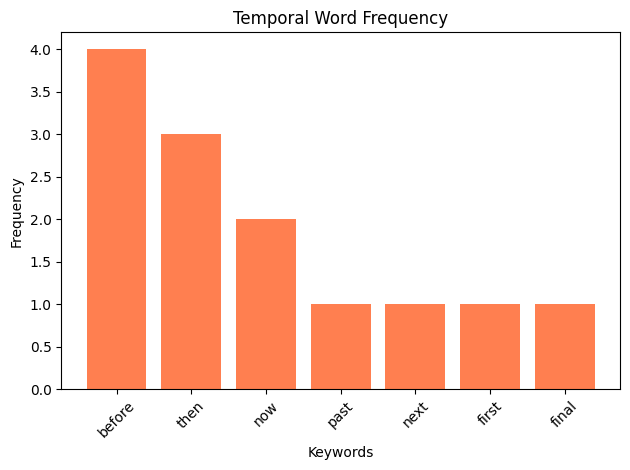

In [ ]:
import matplotlib.pyplot as plt

sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_results.keys(), sorted_results.values(), color='coral')

plt.title('Temporal Word Frequency')
plt.xlabel('Keywords')
plt.ylabel('Frequency')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import numpy as np

# Modeli yükle
try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Veriyi İşleme
doc = nlp(text)
data = []
for token in doc:
    if not token.is_punct and not token.is_space:
        data.append({"word": token.text, "pos": token.pos_})

df = pd.DataFrame(data)

# HATALI KISIM DÜZELTİLDİ:
# Metni 5 bölüme ayırıyoruz (0,0,0,1,1,1... şeklinde etiketler)
df['period'] = pd.cut(df.index, bins=5, labels=False)

print("Veri hazırlandı! Şimdi diğer cell'leri çalıştırabilirsin.")

Veri hazırlandı! Şimdi diğer cell'leri çalıştırabilirsin.


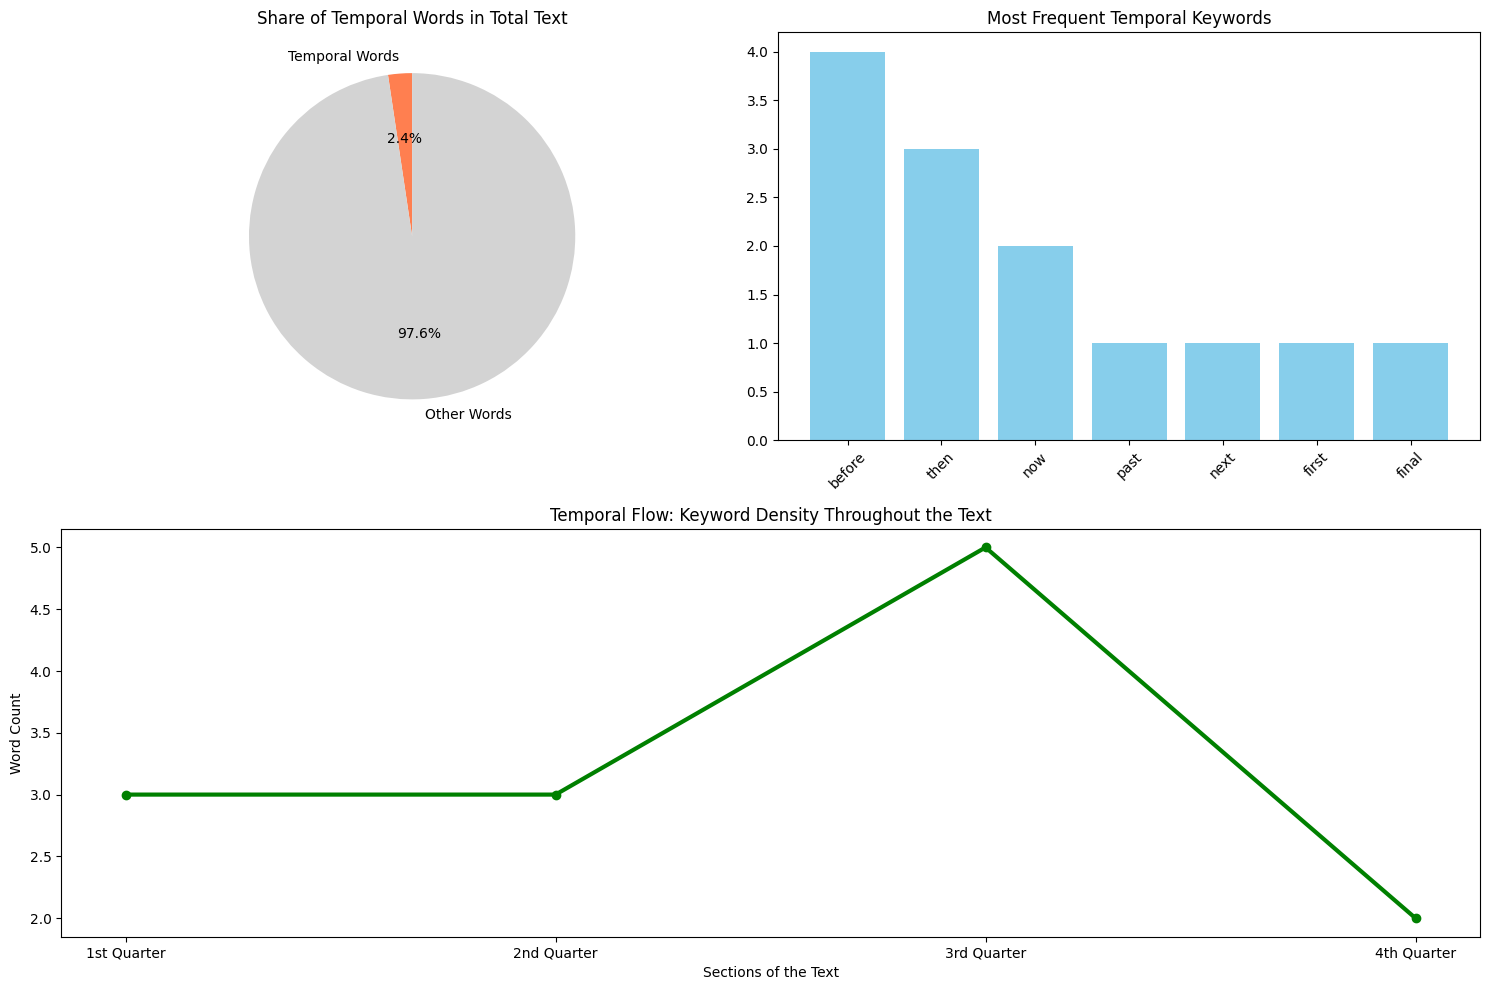

--- ANALYSIS SUMMARY ---
Total Word Count: 550
Total Temporal Keywords Found: 13
Most Frequently Used Keyword: 'before'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import re
from collections import Counter

# 1. Setup and Keyword List
# Make sure to run !python -m spacy download en_core_web_sm if not already installed
nlp = spacy.load("en_core_web_sm")

# 2. Text Analysis
doc = nlp(text)
# Filtering punctuation and whitespace
words_in_text = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]
total_word_count = len(words_in_text)

# Search for keywords from your custom list in the text
found_temporal_counts = {}
clean_text = text.lower()

for word in set(temporal_keywords):
    # Regex to find whole word matches only
    count = len(re.findall(rf'\b{re.escape(word)}\b', clean_text))
    if count > 0:
        found_temporal_counts[word] = count

# 3. Visualization
fig = plt.figure(figsize=(15, 10))

# --- PLOT 1: Pie Chart (Ratio of Temporal Words to Total Text) ---
ax1 = plt.subplot(2, 2, 1)
temporal_total = sum(found_temporal_counts.values())
others_total = total_word_count - temporal_total
ax1.pie([temporal_total, others_total], labels=['Temporal Words', 'Other Words'],
        autopct='%1.1f%%', startangle=90, colors=['coral', 'lightgrey'])
ax1.set_title("Share of Temporal Words in Total Text")

# --- PLOT 2: Bar Chart (Top Frequency Temporal Words) ---
ax2 = plt.subplot(2, 2, 2)
# Sorting to show the top 10 most used temporal words
sorted_counts = dict(sorted(found_temporal_counts.items(), key=lambda x: x[1], reverse=True))
ax2.bar(list(sorted_counts.keys())[:10], list(sorted_counts.values())[:10], color='skyblue')
ax2.set_title("Most Frequent Temporal Keywords")
plt.xticks(rotation=45)

# --- PLOT 3: Temporal Flow (Distribution across Narrative) ---
# Dividing the text into 4 quartiles to see the density shift
ax3 = plt.subplot(2, 1, 2)
chunks = 4
chunk_size = len(words_in_text) // chunks
temporal_flow = []

for i in range(chunks):
    start, end = i * chunk_size, (i + 1) * chunk_size
    chunk_words = " ".join(words_in_text[start:end])
    # Counting keywords in each specific quarter
    chunk_count = sum(len(re.findall(rf'\b{re.escape(w)}\b', chunk_words)) for w in temporal_keywords)
    temporal_flow.append(chunk_count)

ax3.plot(["1st Quarter", "2nd Quarter", "3rd Quarter", "4th Quarter"], temporal_flow,
         marker='o', color='green', linewidth=3)
ax3.set_title("Temporal Flow: Keyword Density Throughout the Text")
ax3.set_ylabel("Word Count")
ax3.set_xlabel("Sections of the Text")

plt.tight_layout()
plt.show()

# 4. Summary Report
print(f"--- ANALYSIS SUMMARY ---")
print(f"Total Word Count: {total_word_count}")
print(f"Total Temporal Keywords Found: {temporal_total}")
if found_temporal_counts:
    most_common = max(found_temporal_counts, key=found_temporal_counts.get)
    print(f"Most Frequently Used Keyword: '{most_common}'")
else:
    print("No keywords from the list were found in the text.")

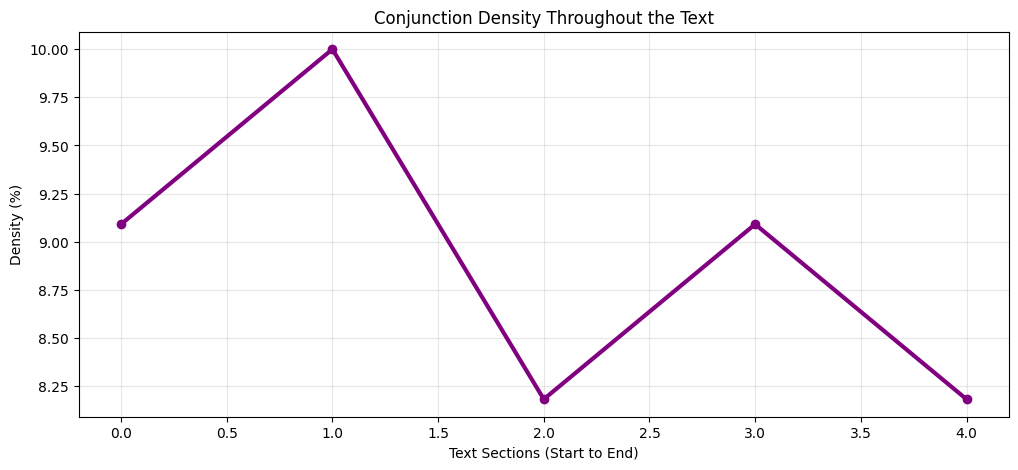

In [ ]:
# Group words by period and part-of-speech (POS)
temporal_data = df.groupby(['period', 'pos']).size().unstack(fill_value=0)

# Calculate percentage by dividing by total words in each period
temporal_pct = temporal_data.div(temporal_data.sum(axis=1), axis=0) * 100

# Identify conjunction columns (Check if CCONJ or SCONJ exist in the dataset)
conj_cols = [c for c in ['CCONJ', 'SCONJ'] if c in temporal_pct.columns]

plt.figure(figsize=(12, 5))

if conj_cols:
    # Plot the sum of conjunction types over time
    temporal_pct[conj_cols].sum(axis=1).plot(marker='o', color='purple', linewidth=3)

    plt.title("Conjunction Density Throughout the Text")
    plt.xlabel("Text Sections (Start to End)")
    plt.ylabel("Density (%)")
    plt.grid(True, alpha=0.3)
else:
    print("No conjunctions found in the text.")

plt.show()

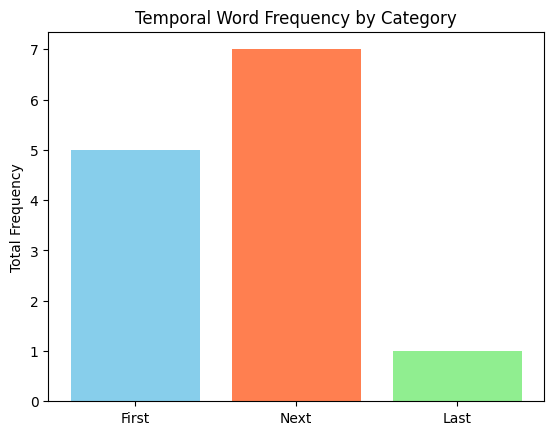

In [ ]:
import matplotlib.pyplot as plt
import re

first_keywords = ["at first", "at that moment", "at the beginning", "at the onset",
    "before", "commence", "choose", "first", "first of all",
    "from this point", "in the first place", "one day", "one evening",
    "one morning", "starting with", "to begin"]
next_keywords = ["a moment later", "after", "after a few days", "after a while",
    "after that", "afterwards", "all of a sudden", "as soon as",
    "at that very moment", "at times", "before long", "consequently",
    "during", "earlier", "eventually", "following", "formerly",
    "from time to time", "gradually", "henceforth", "in addition",
    "in the meantime", "in the past", "in time", "in turn", "later",
    "later on", "meanwhile", "momentarily", "next", "next week",
    "not a moment too soon", "not long after", "not long ago", "now",
    "occasionally", "once", "past", "periodically", "preceding",
    "presently", "previously", "prior to", "rarely", "right after",
    "second", "seldom", "shortly", "shortly after this", "since",
    "some of the time", "soon", "soon after", "suddenly", "then",
    "therefore", "third", "tomorrow", "up until that time", "when",
    "whenever", "yesterday"]
last_keywords = ["after a long time", "afterward", "at last", "at the end",
    "eventually", "final", "finally", "hereafter", "in conclusion",
    "in the end", "last of all", "lastly", "later on", "thereafter",
    "to conclude", "to finish", "ultimately", "until", "one day"]

categories = {
    "First": first_keywords,
    "Next": next_keywords,
    "Last": last_keywords
}

clean_text = text.lower()

category_counts = {}
for cat_name, keywords in categories.items():
    total = 0
    for word in set(keywords):
        total += len(re.findall(rf'\b{re.escape(word)}\b', clean_text))
    category_counts[cat_name] = total

plt.bar(category_counts.keys(), category_counts.values(), color=['skyblue', 'coral', 'lightgreen'])
plt.title('Temporal Word Frequency by Category')
plt.ylabel('Total Frequency')
plt.show()

This code snippet determines the positions of the temporal conjunctions in the text. In the given example, we see that the text is going in the cronological order, starting with before ending with after. No need to make changes in this one either, you can just run this cell as well.

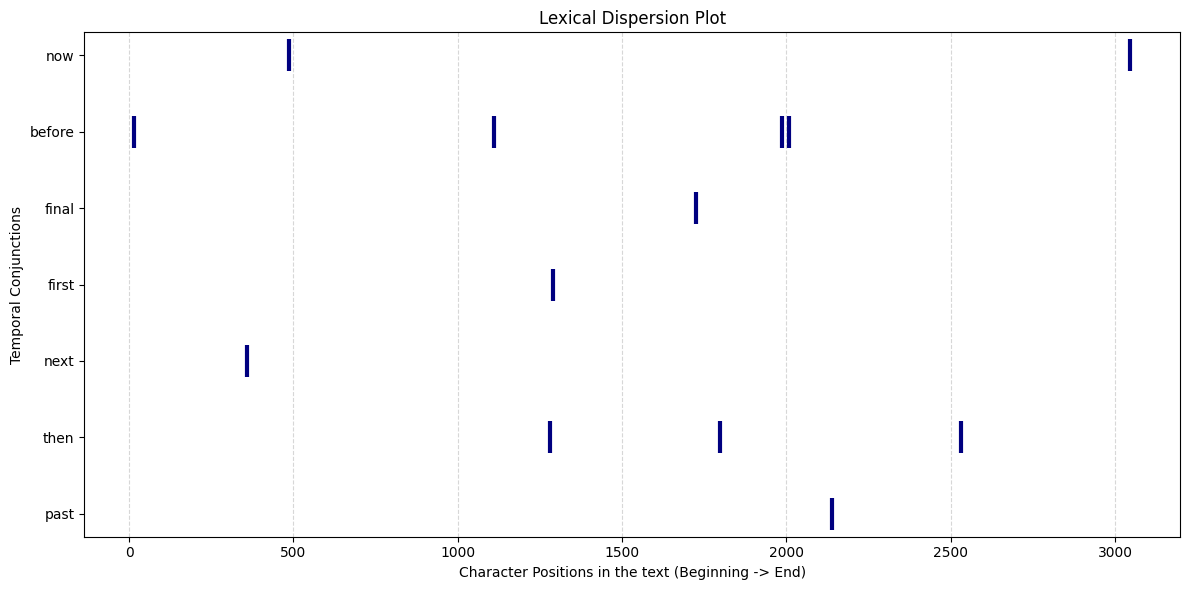

In [ ]:
import matplotlib.pyplot as plt
import re

#finding the positions of the word in the text
word_positions = []
for word in temporal_keywords:
    # finding the starting index of every word
    #regex....
    matches = re.finditer(rf'\b{re.escape(word)}\b', text.lower())
    for match in matches:
        word_positions.append({
            'Word': word,
            'Position': match.start() #order of the word in the text
        })

plt.figure(figsize=(12, 6))

# every temporal word will be in the Y-axis
for i, word in enumerate(temporal_keywords):
    positions = [p['Position'] for p in word_positions if p['Word'] == word]

    # positions x axis word name on y axis
    # marker -> |
    plt.scatter(positions, [word] * len(positions), color='navy', marker='|', s=500, linewidths=3)

plt.title('Lexical Dispersion Plot')
plt.xlabel('Character Positions in the text (Beginning -> End)')
plt.ylabel('Temporal Conjunctions')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

This part is the network analysis, far from perfect, I clustered the verbs into three categories: action, cognitive, stative. And this one could go wrong easily with more worded texts so any kind of suggestions and improvements would be appreciated.

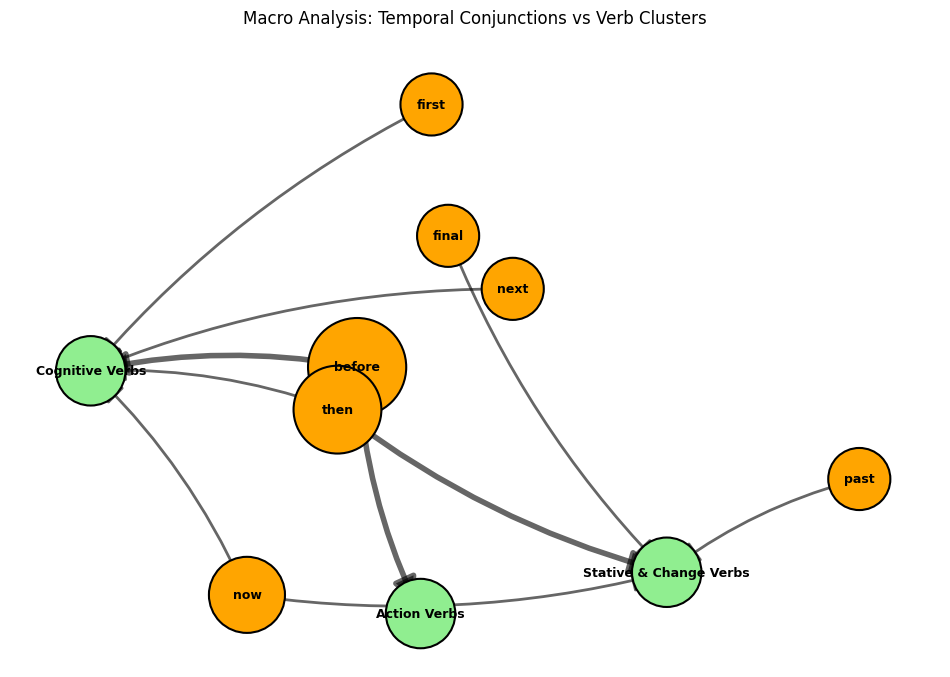

In [ ]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter

nlp = spacy.load("en_core_web_md")

def get_ultimate_verb(token):

    #If the word that the conjunction is connected is not a verb(noun for example) it continues until it find the main verb
    curr = token
    for _ in range(10):
        if curr.head == curr:
            break
        if curr.head.pos_ == "VERB":
            return curr.head
        curr = curr.head
    return None

def draw_macro_temporal_network(text_input, keywords_input):
    doc = nlp(text_input)

    # find verbs
    all_verbs = [token.lemma_.lower() for token in doc if token.pos_ == "VERB"]
    unique_verbs = list(set(all_verbs))

    # clustering the verbs
    verb_vectors = np.array([nlp(v).vector for v in unique_verbs])
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(verb_vectors)
    verb_to_cluster = {verb: cluster for verb, cluster in zip(unique_verbs, clusters)}

    # node names
    cluster_labels = {0: "Action Verbs", 1: "Cognitive Verbs", 2: "Stative & Change Verbs"}

    # counting
    edge_counts = Counter()
    conjunction_counts = Counter()

    for token in doc:
        word = token.text.lower()
        if word in keywords_input:
            conjunction_counts[word] += 1

            #finding the verb in the hierarchy for overlooked connections not 100% sure on this part
            target_verb = get_ultimate_verb(token)

            if target_verb:
                cluster_id = verb_to_cluster.get(target_verb.lemma_.lower())
                if cluster_id is not None:
                    target_node = cluster_labels[cluster_id]
                    edge_counts[(word, target_node)] += 1

    G = nx.DiGraph()

    node_colors = {}
    node_sizes = {}

    # adding the conjunction nodes
    for conj in conjunction_counts:
        G.add_node(conj)
        node_colors[conj] = "orange"
        node_sizes[conj] = 1000 + (conjunction_counts[conj] * 1000)

    # adding the cluster nodes
    for label in cluster_labels.values():
        G.add_node(label)
        node_colors[label] = "lightgreen"
        node_sizes[label] = 2500

    #adding the edges
    for (u, v), weight in edge_counts.items():
        G.add_edge(u, v, weight=weight)

    plt.figure(figsize=(12, 8))
    # Shell layout
    pos = nx.spring_layout(G, k=1.2, seed=42)

    # drawing the nodes
    colors = [node_colors.get(n, "gray") for n in G.nodes()]
    sizes = [node_sizes.get(n, 1000) for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, edgecolors="black", linewidths=1.5)

    # drawing the edges, thickness depends on the weights
    if G.edges():
        weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=weights, edge_color="black", arrowsize=35, alpha=0.6, connectionstyle="arc3,rad=0.1")

    #labels
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

    plt.title("Macro Analysis: Temporal Conjunctions vs Verb Clusters", pad=20)
    plt.axis('off')
    plt.show()

draw_macro_temporal_network(text, temporal_keywords)

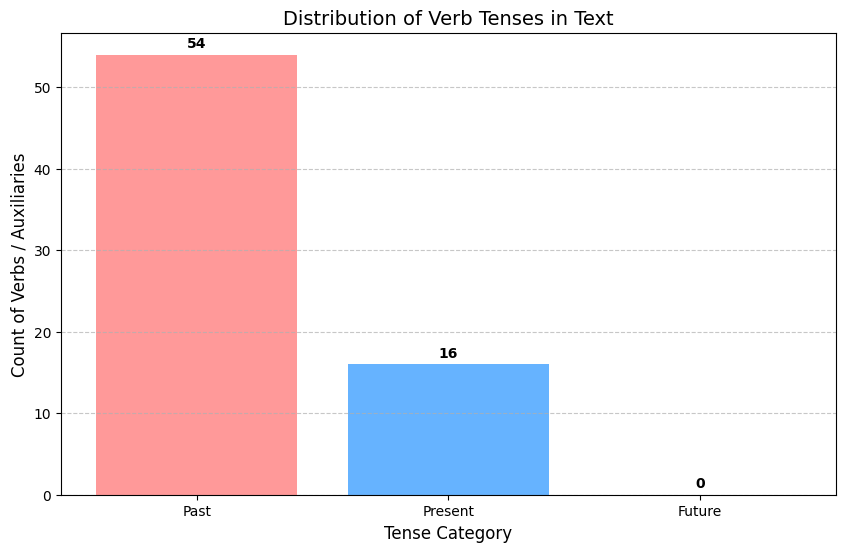

Zaman Dağılımı: {'Past': 54, 'Present': 16, 'Future': 0}
Örnekler (Past): ['saw', 'accreted', 'expanded', 'looked', 'were', 'flew', 'searched', 'passed', 'stalled', 'been']


In [ ]:
import matplotlib.pyplot as plt
import spacy
from collections import Counter

# Spacy modelini yükle (zaten yüklüyse tekrar yüklemene gerek yok)
nlp = spacy.load("en_core_web_md")

def analyze_verb_tenses(text_input):
    doc = nlp(text_input)

    # Zaman kategorileri için sayaçlar
    tenses = {
        "Past": 0,
        "Present": 0,
        "Future": 0
    }

    # Örnek fiil listesi (Hangi kelimenin nereye gittiğini görmek için)
    tense_examples = {"Past": [], "Present": [], "Future": []}

    for i, token in enumerate(doc):
        if token.pos_ == "VERB" or token.pos_ == "AUX":
            word = token.text.lower()
            lemma = token.lemma_.lower()
            tag = token.tag_ # Detaylı POS tag (VBD: past, VBG: gerund vb.)

            # --- 1. FUTURE TENSE KONTROLÜ ---
            # 'will' veya 'going to' yapısı
            next_words = [t.text.lower() for t in doc[i:i+4]] # İleriye dönük 4 kelimeye bak
            if word == "will" or ("going" in next_words and "to" in next_words):
                tenses["Future"] += 1
                tense_examples["Future"].append(word)
                continue # Diğer kontrollere girme

            # --- 2. PAST TENSE KONTROLÜ ---
            # was, were, had veya VBD (past tense) / VBN (past participle)
            elif tag in ["VBD", "VBN"] or word in ["was", "were", "had", "did"]:
                tenses["Past"] += 1
                tense_examples["Past"].append(word)

            # --- 3. PRESENT TENSE KONTROLÜ ---
            # VBP, VBZ (present) veya am, is, are, do, has
            elif tag in ["VBP", "VBZ"] or word in ["am", "is", "are", "do", "has", "have"]:
                tenses["Present"] += 1
                tense_examples["Present"].append(word)

    # --- GRAFİK OLUŞTURMA ---
    plt.figure(figsize=(10, 6))
    colors = ['#ff9999','#66b3ff','#99ff99'] # Past: Kırmızımsı, Present: Mavi, Future: Yeşil

    bars = plt.bar(tenses.keys(), tenses.values(), color=colors)

    # Barların üzerine sayıları yazalım
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom', fontweight='bold')

    plt.title('Distribution of Verb Tenses in Text', fontsize=14)
    plt.xlabel('Tense Category', fontsize=12)
    plt.ylabel('Count of Verbs / Auxiliaries', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    return tenses, tense_examples

# Analizi çalıştır
tense_counts, examples = analyze_verb_tenses(text)

print("Zaman Dağılımı:", tense_counts)
print("Örnekler (Past):", list(set(examples["Past"]))[:10])

In [ ]:
import os
from google.colab import drive

# 1. Drive'ı sisteme bağla (Gelen onay penceresini kabul et)
drive.mount('/content/drive')

# 2. Klasör Yolunu Belirle
# 'Klasör_Adı' kısmını Drive'ına eklediğin kısayolun tam adıyla değiştir
FOLDER_PATH = '/content/drive/MyDrive/Klasör_Adı/'

# 3. Dosyaları Listele ve Analiz Et
if os.path.exists(FOLDER_PATH):
    files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.txt')]
    print(f"Bulunan dosyalar: {files}")

    for file_name in files:
        # Burada senin analiz fonksiyonun devreye girecek
        # Analiz bittiğinde kaydetmek için şu komutu kullanacağız:
        # plt.savefig(f"{FOLDER_PATH}{file_name}_analiz.png")
        print(f"{file_name} analiz ediliyor ve görsel olarak kaydediliyor...")
else:
    print("Klasör yolu bulunamadı! Lütfen yolu kontrol et.")